In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import scipy

In [2]:
data = pd.read_csv("loan_risk_prediction_dataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   str    
 6   Education        4802 non-null   str    
 7   City             5000 non-null   str    
 8   EmploymentType   5000 non-null   str    
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 544.3 KB


In [3]:
data.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [4]:
data.isna().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [5]:
data.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [6]:
data.corr(numeric_only = True)

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
Age,1.000000,-0.000531,-0.011822,0.003363,-0.014192,-0.008754
Income,-0.000531,1.000000,0.002607,-0.049995,-0.016022,0.190897
LoanAmount,-0.011822,0.002607,1.000000,0.003665,0.012145,0.018302
CreditScore,0.003363,-0.049995,0.003665,1.000000,-0.003130,0.464790
YearsExperience,-0.014192,-0.016022,0.012145,-0.003130,1.000000,-0.006372
LoanApproved,-0.008754,0.190897,0.018302,0.464790,-0.006372,1.000000


In [7]:
newData = data.copy()

In [8]:
import numpy as np
newData['Income'] = newData['Income'].fillna(newData['Income'].median())
newData['CreditScore'] = newData['CreditScore'].fillna(newData['CreditScore'].median())

In [9]:
newData['Gender'] = newData['Gender'] = np.where(newData['Gender'] == 'Male', 1, 0)

In [10]:
newData.head(13)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,0,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,1,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,1,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,1,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,0,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,1,Masters,New York,Salaried,1
6,38,54748.0,25374.0,760.0,9,0,High School,New York,Self-Employed,1
7,56,49488.0,6279.0,599.0,22,1,PhD,New York,Unemployed,0
8,36,25918.0,25041.0,777.0,29,0,Bachelors,San Francisco,Unemployed,0
9,40,43415.0,2065.0,382.0,30,0,High School,San Francisco,Self-Employed,0


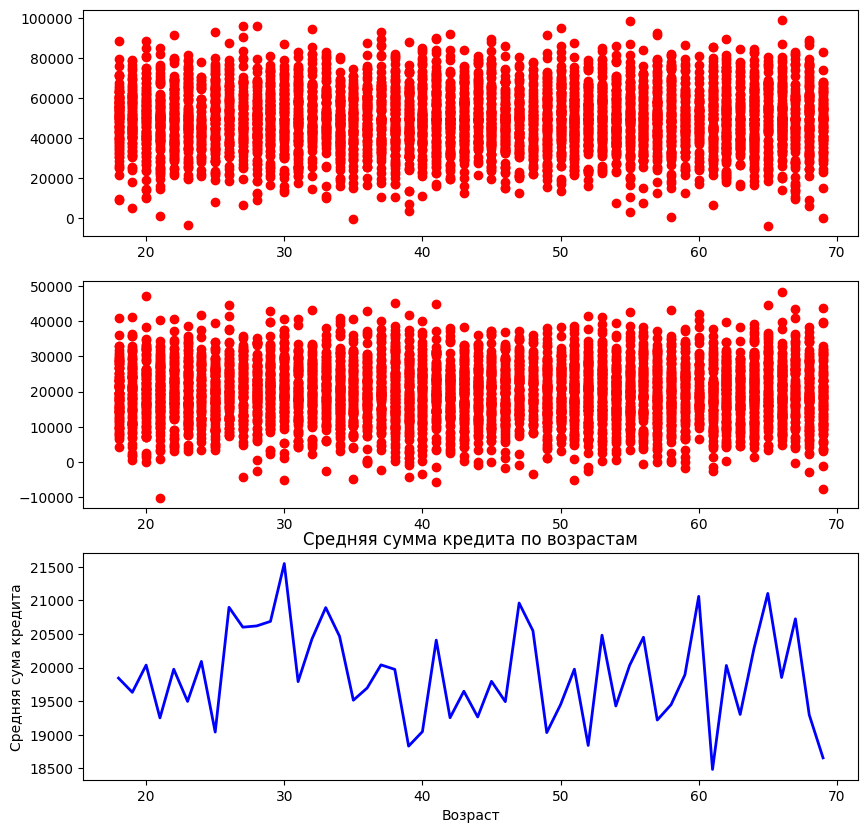

In [11]:
fig, ax = plt.subplots(3,1, figsize = (10,10))
MeanOfAge = newData.groupby('Age')['LoanAmount'].mean()

ax[0].scatter(newData['Age'],newData['Income'], color = 'red')
ax[1].scatter(newData['Age'],newData['LoanAmount'], color = 'red')
ax[2].plot(MeanOfAge.index, MeanOfAge.values, color = 'blue',linewidth = 2)
ax[2].set_xlabel('Возраст')
ax[2].set_ylabel('Средняя сума кредита')
ax[2].set_title('Средняя сумма кредита по возрастам')
plt.show()

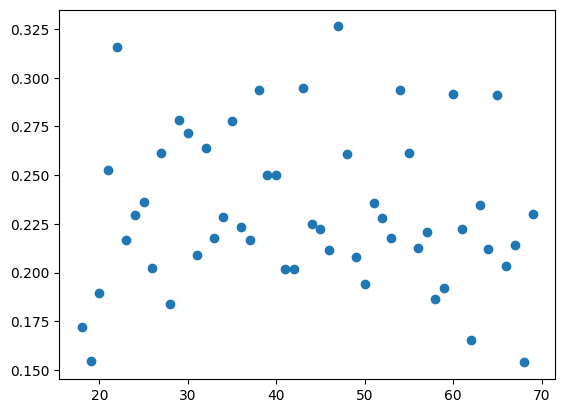

In [12]:
ApproveAge = newData.groupby('Age')['LoanApproved'].mean()
plt.scatter(ApproveAge.index, ApproveAge.values)
plt.show()

Что я могу сказать:
1) Кредитная история и уровень заработной планы важные признаки
2) От 30 до 40 лет самые лучшие клиенты - а так же им охотнее выдаётся кредит
3) Признак кредитной истории - из-за него модель может переобучиться и сделать больший вес на него
4) Из датасета видно, что дисбаланс классов сильный
5) Для начала можно убрать признак город - он может создать излишний шум при обучении
6) Надо почистить данные с отрицательными значениями!
7) Дасет небольшой - большие модели ни к чему (как и PyTorch на текущий момент) - нет смысла на малой выборке данных строить сложные модели. Можно предварительно обучить модель логистической регрессии - если результат удовлетворит, то не будем строить ансамбль логистических деревьев. Но предварительно придётся использовать $L_{2}$ регуляризацию для уравновешивания весов (кредитная история может забрать почти все на себя, и на выходе получим строго линейный классификатор)

In [13]:
newData['Income'] = np.where(newData['Income'] < 0, abs(newData['Income']), newData['Income'])
newData['LoanAmount'] = np.where(newData['LoanAmount'] < 0, abs(newData['LoanAmount']), newData['LoanAmount'])

Для того, чтобы признак города не пропадал - будем использовать среднюю зарплату по городу. Видим город - заменяем значением средней зарплаты по нему. Это будет более весомый признак для модели, поскольку мы даём конкретику, а не семантику (модель не может знать, какой город лучше - а в попытках определить, провалит свою главную задачу - определение хорошего клиента)

In [14]:
MeanIncomeFromCity = newData.groupby('City')['Income'].mean()

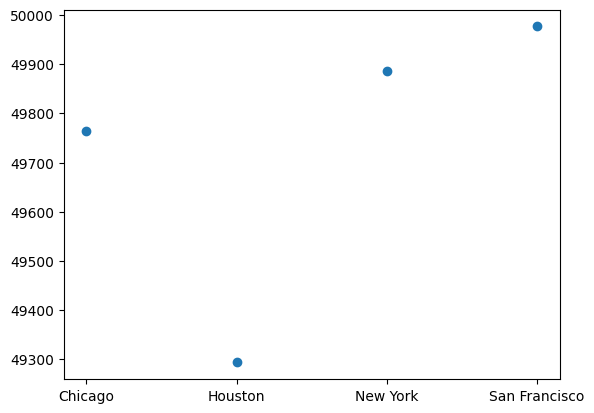

In [15]:
plt.scatter(MeanIncomeFromCity.index, MeanIncomeFromCity.values)
plt.show()

In [16]:
newData['City'] = newData['City'].map(MeanIncomeFromCity)

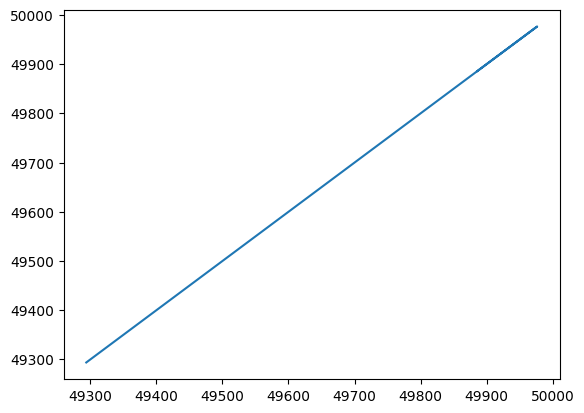

In [17]:
plt.plot(newData['City'],newData['City'])
plt.show()

In [18]:
newData.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,0,High School,49293.743506,Unemployed,0
1,69,57462.0,23262.0,586.0,6,1,High School,49976.618138,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,1,PhD,49293.743506,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,1,NaN,49885.968517,Unemployed,0
4,60,37034.0,27871.0,500.0,19,0,High School,49764.401840,Unemployed,0


In [19]:
print(newData.isna().sum()) 

Age                  0
Income               0
LoanAmount           0
CreditScore          0
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64


In [20]:
newData.drop('Education',axis = 1)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,0,49293.743506,Unemployed,0
1,69,57462.0,23262.0,586.0,6,1,49976.618138,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,1,49293.743506,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,1,49885.968517,Unemployed,0
4,60,37034.0,27871.0,500.0,19,0,49764.401840,Unemployed,0
...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,579.0,23,1,49293.743506,Salaried,0
4996,66,99146.0,9760.0,306.0,14,1,49885.968517,Unemployed,0
4997,26,58100.0,18230.0,311.0,10,0,49976.618138,Self-Employed,0
4998,53,58513.0,12373.0,813.0,23,1,49293.743506,Salaried,1


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience','City','Gender']
newData[cols] = scaler.fit_transform(newData[cols])

In [22]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression

Xtrain, Xtest, Ytrain , Ytest = train_test_split(newData[cols], newData['LoanApproved'],
                                                stratify = newData['LoanApproved'],
                                                train_size = 0.8,
                                                test_size = 0.2, 
                                                random_state = 42)

In [23]:
model = LogisticRegression(class_weight = {1: 1.0, 0: 1.6})
model.fit(Xtrain,Ytrain)
Predict = model.predict(Xtest)

In [24]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix, f1_score
print("Confusion Matrix:")
print(confusion_matrix(Ytest, Predict))
print("Precision:")
print(precision_score(Ytest, Predict))
print("Recall:")
print(recall_score(Ytest, Predict))
print("F1-score:")
print(f1_score(Ytest, Predict))

Confusion Matrix:
[[735  35]
 [163  67]]
Precision:
0.6568627450980392
Recall:
0.29130434782608694
F1-score:
0.4036144578313253


In [130]:
for name, coef in zip(cols, model.coef_[0]):
    print(f'{name:20s}: {coef:+.4f}')

Age                 : -0.0475
Income              : +0.7558
LoanAmount          : +0.0589
CreditScore         : +1.6001
YearsExperience     : +0.0214
City                : +0.0522
Gender              : +0.0224


In [120]:
from sklearn.ensemble import RandomForestClassifier

modelA = RandomForestClassifier(
        random_state = 42, 
        class_weight = {0: 1, 1: 1.4},
        max_depth = 10, 
        n_estimators = 100,
        min_samples_leaf=5)

modelA.fit(Xtrain, Ytrain)
predictA = modelA.predict(Xtest)

In [121]:
print("Random Forest:")
print(confusion_matrix(Ytest, predictA))
print(f"Precision: {precision_score(Ytest, predictA):.3f}")
print(f"Recall:    {recall_score(Ytest, predictA):.3f}")
print(f"F1-score:  {f1_score(Ytest, predictA):.3f}")

Random Forest:
[[643 127]
 [ 26 204]]
Precision: 0.616
Recall:    0.887
F1-score:  0.727


In [132]:
# Универсально — через get_params()
print(modelA.get_params())
print()
for name, imp in zip(cols, modelA.feature_importances_):
    print(f'{name:20s}: {imp:.4f}')

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': {0: 1, 1: 1.4}, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Age                 : 0.0340
Income              : 0.2518
LoanAmount          : 0.0414
CreditScore         : 0.6274
YearsExperience     : 0.0302
City                : 0.0104
Gender              : 0.0049


In [32]:
# Random Forest:
# [[646 124]
#  [ 23 207]]
# Precision: 0.625
# Recall:    0.900
# F1-score:  0.738

In [127]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators= 100,
    max_depth = 15,
    learning_rate = 0.2,
    scale_pos_weight = 1.5,   
    random_state = 42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(Xtrain, Ytrain)
xgb_pred = xgb.predict(Xtest)

print("XGBoost:")
print(confusion_matrix(Ytest, xgb_pred))
print(f"Precision: {precision_score(Ytest, xgb_pred):.3f}")
print(f"Recall:    {recall_score(Ytest, xgb_pred):.3f}")
print(f"F1-score:  {f1_score(Ytest, xgb_pred):.3f}")

XGBoost:
[[665 105]
 [ 59 171]]
Precision: 0.620
Recall:    0.743
F1-score:  0.676


D:\vsPython\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:24:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [133]:
for name, imp in zip(cols, xgb.feature_importances_):
    print(f'{name:20s}: {imp:.4f}')

Age                 : 0.0760
Income              : 0.2086
LoanAmount          : 0.0826
CreditScore         : 0.3996
YearsExperience     : 0.0815
City                : 0.0746
Gender              : 0.0772


In [201]:
cols_xgb = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']

# Стандартизация
newData[cols_xgb] = scaler.fit_transform(newData[cols_xgb])

# Разделение
Xtrain_xgb, Xtest_xgb, Ytrain_xgb, Ytest_xgb = train_test_split(
    newData[cols_xgb], newData['LoanApproved'],
    stratify=newData['LoanApproved'],
    test_size=0.2,
    random_state=42
)

# Модель
xgb2 = XGBClassifier(
    n_estimators = 208,
    max_depth = 3,
    learning_rate = 0.025,
    scale_pos_weight= 2.5,
    random_state=42,
    eval_metric='logloss'
)

xgb2.fit(Xtrain_xgb, Ytrain_xgb)
xgb2_pred = xgb2.predict(Xtest_xgb)

print(confusion_matrix(Ytest_xgb, xgb2_pred))
print(f"Precision: {precision_score(Ytest_xgb, xgb2_pred):.3f}")
print(f"Recall:    {recall_score(Ytest_xgb, xgb2_pred):.3f}")
print(f"F1-score:  {f1_score(Ytest_xgb, xgb2_pred):.3f}")

[[640 130]
 [ 23 207]]
Precision: 0.614
Recall:    0.900
F1-score:  0.730
